In [2240]:
import math
import numpy as np
import matplotlib.pyplot as plt
import random
%matplotlib inline

In [2241]:
def f(x):
    return 3*x**2 - 4*x + 5

f(3.0)

20.0

array([-5.  , -4.75, -4.5 , -4.25, -4.  , -3.75, -3.5 , -3.25, -3.  ,
       -2.75, -2.5 , -2.25, -2.  , -1.75, -1.5 , -1.25, -1.  , -0.75,
       -0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,
        1.75,  2.  ,  2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,
        4.  ,  4.25,  4.5 ,  4.75])

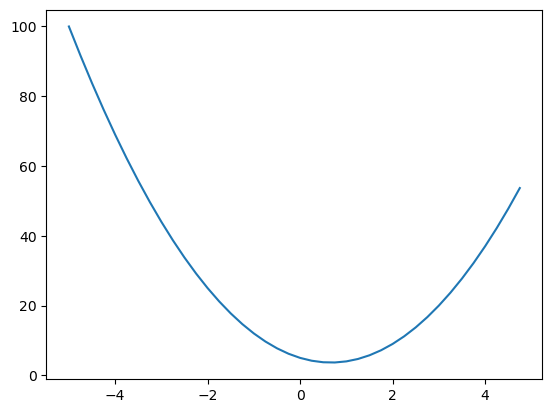

In [2242]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)
xs

In [2243]:
# Derivative Numerical Approximation
h = 0.001
x = 2/3
(f(x + h) - f(x)) / h

0.0029999999995311555

In [2244]:
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [2245]:
h = 0.0001

a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a += h  # where f = ab + c, df/da = b = -3
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1)/h)

d1 4.0
d2 3.999699999999999
slope -3.000000000010772


In [2246]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward

        return out
    
    def __radd__(self, other):  # other + self
        return self + other

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward

        return out
    
    def __rmul__(self, other):
        return self * other

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float power for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward

        return out

    def __truediv__(self, other):
        return self * other**-1

    def __rtruediv__(self, other): # other / self
        return other * self**-1
    
    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)
    
    def __rsub__(self, other):  # other - self
        return other + (-self)

    def tanh(self):
        n = self.data
        t = (math.exp(2*n) - 1)/(math.exp(2*n) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward

        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward

        return out
    
    def backward(self):
        topo = []
        visited = set()
        
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [2247]:
a = Value(2.0)
2*a
a.exp()
a-b


Value(data=5.0)

In [2248]:
a = Value(2.0)
b = Value(4.0)
# a/b = a * (1/b) = a * b^(-1)

a/b

Value(data=0.5)

In [2249]:
# Visualize DAG
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v) 
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

## Neuron
Weighted sum of inputs, plus a bias, passed through an activation function.

Below, we have a neuron with 2 inputs, a bias, and the tanh activation function.


In [2250]:
### Define a Neuron
# Inputs: x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# Weights: w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# Bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
# Activation Function
o = n.tanh(); o.label = 'o'
o.backward()

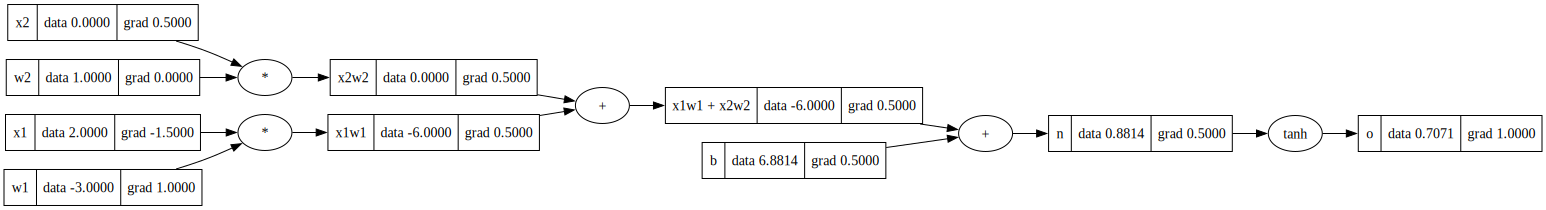

In [2251]:
draw_dot(o)

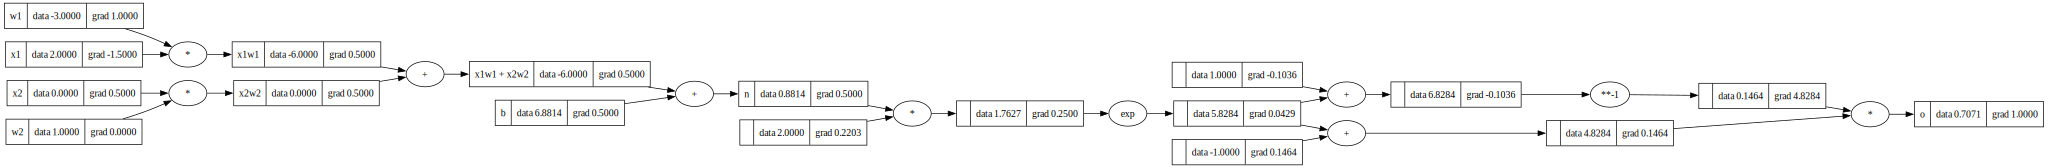

In [2252]:
### Define a Neuron
# Inputs: x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# Weights: w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# Bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'
# Activation Function (equivalnet to tanh)
e = (2*n).exp()
o = (e - 1)/(e + 1)
o.label = 'o'
o.backward()
draw_dot(o)

In [2253]:
import torch

In [2254]:
x1 = torch.Tensor([2.0]).double()               ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()               ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()              ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()               ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double() ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x1', x1.grad.item())
print('w1', w1.grad.item())
print('x2', x2.grad.item())
print('w2', w2.grad.item())

0.7071066904050358
---
x1 -1.5000003851533106
w1 1.0000002567688737
x2 0.5000001283844369
w2 0.0


In [2255]:
x2.grad.item()

0.5000001283844369

In [2256]:
class Neuron:

    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]  # randomly initialized
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        # w * x + b
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]

class Layer:

    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:

    def __init__(self, nin, nouts):
        sz = [nin] + nouts  # list of layer sizes
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [2257]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=0.7382075574009423)

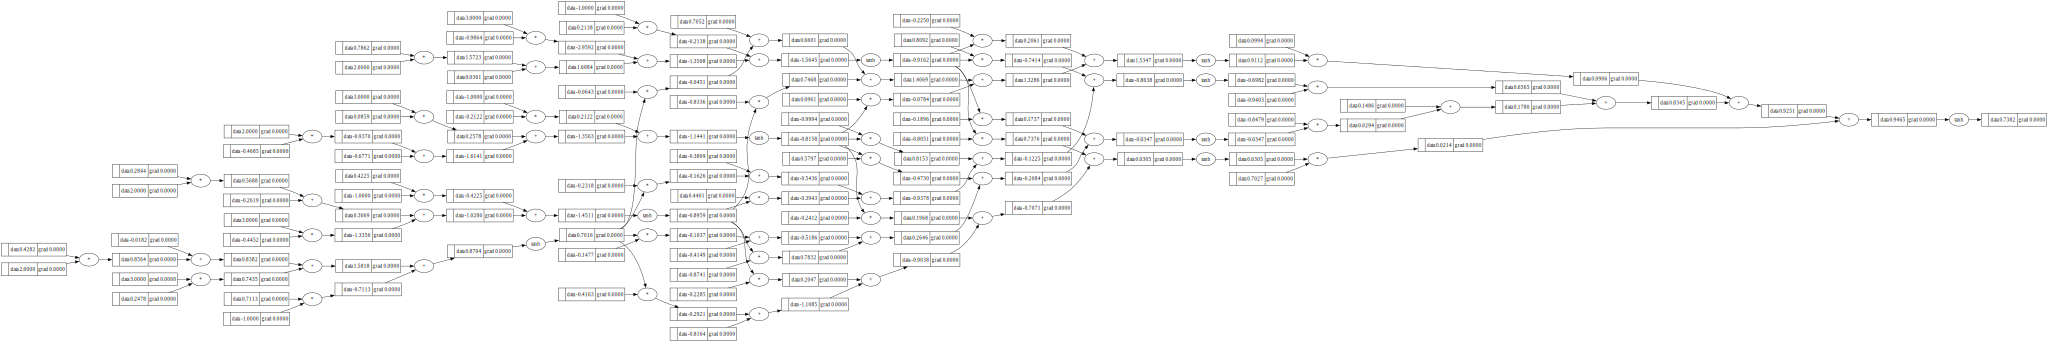

In [2258]:
draw_dot(n(x))  # draws one forward pass in the the 2 layer neural net

In [2259]:
### Example Dataset
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]

In [2260]:
### Loss Function: Squared losses
ypred = [n(x) for x in xs]  # forward pass
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=2.6824259515403797)

In [2261]:
for k in range(2000):
    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    # backward pass
    for p in n.parameters():
        p.grad = 0.0  # == p.zero_grad()
    loss.backward()

    # update
    for p in n.parameters():
        p.data -= 0.05 * p.grad

    print(k, loss.data)

0 2.6824259515403797
1 1.2776589080366214
2 0.5740463826516895
3 0.30916847983048906
4 0.20678909419526914
5 0.15648623719520943
6 0.12508464694052734
7 0.10376396835241115
8 0.08841070920445918
9 0.0768630158717543
10 0.06788225651697768
11 0.06071037295691502
12 0.054858647607754246
13 0.049998463974232535
14 0.04590104813818037
15 0.04240242162384549
16 0.03938209535383885
17 0.03674962174348968
18 0.034435828481502374
19 0.03238694180948429
20 0.030560548917719567
21 0.02892276302160466
22 0.027446194021623294
23 0.026108470441763558
24 0.02489114594603431
25 0.02377887884224763
26 0.02275880844160683
27 0.021820075430146864
28 0.020953448989547697
29 0.020151034009493286
30 0.01940603906504319
31 0.01871259097442452
32 0.018065585407449576
33 0.017460565644833836
34 0.016893623503224195
35 0.016361317849426172
36 0.01586060717423185
37 0.015388793481633082
38 0.014943475343599568
39 0.014522508424192749
40 0.014123972125637891
41 0.013746141279257398
42 0.013387462015035653
43 0.0

In [2262]:
ypred

[Value(data=0.9941526038427373),
 Value(data=-0.9949295058351372),
 Value(data=-0.98954721914006),
 Value(data=0.992221693136356)]

In [2263]:
n.parameters()

[Value(data=0.28667965066921547),
 Value(data=0.07653108101488652),
 Value(data=0.8525561822813964),
 Value(data=-0.11386065907775354),
 Value(data=0.32255013710601943),
 Value(data=-0.32529701001644223),
 Value(data=0.7061864506163976),
 Value(data=-0.11347775974444531),
 Value(data=-0.4403231009888878),
 Value(data=0.07542606694293762),
 Value(data=-0.3732555614360691),
 Value(data=-0.7003430818614028),
 Value(data=0.6843247582756516),
 Value(data=-0.8782272279621539),
 Value(data=0.9824333490244148),
 Value(data=0.18024901087428838),
 Value(data=-0.020650887394332733),
 Value(data=-0.6735116011957589),
 Value(data=0.6437734104414118),
 Value(data=-0.007032140144076472),
 Value(data=-0.5271104996481152),
 Value(data=0.10907342047049699),
 Value(data=0.7194989722816317),
 Value(data=-1.0643545681696351),
 Value(data=1.079780953494847),
 Value(data=-0.35298126194601664),
 Value(data=-0.1553258792264444),
 Value(data=-0.8806439114515436),
 Value(data=0.17830564579438063),
 Value(data=-0

most common neural net mistakes: 
1) you didn't try to overfit a single batch first. 
2) you forgot to toggle train/eval mode for the net. 
3) you forgot to zero_grad() (in pytorch) before .backward(). 
4) you passed softmaxed outputs to a loss that expects raw logits.
5) you didn't use bias=False for your Linear/Conv2d layer when using BatchNorm, or conversely forget to include it for the output layer.